<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/Stats_vul_10k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
!pip install pyvis

import pandas as pd
import numpy as np
import json
import os
import glob
import re


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.6 MB/s eta 0:00:00


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

In [8]:
# import ipywidgets as widgets
# from IPython.display import display
# import glob
# import os


# if not os.path.exists('/content/adsync'):
#     os.makedirs('/content/adsync')
#     print("/content/adsync directory created.")
# else:
#     print("/content/adsync directory already exists.")

# # Get a list of files in the current directory or a specified directory
# file_list = glob.glob('*.json') # You can change the pattern to match your files

# # Create a dropdown widget
# file_dropdown = widgets.Dropdown(
#     options=file_list,
#     description='Select a file:',
#     disabled=False,
# )

# # Create a button widget
# select_button = widgets.Button(
#     description='Select File',
#     disabled=False,
#     button_style='', # 'success', 'info', 'warning', 'danger' or ''
#     tooltip='Click to select the file',
#     icon='check' # (FontAwesome icons: https://fontawesome.com/icons)
# )

# # Output widget to display the selected file
# output_widget = widgets.Output()

# # Function to handle button click
# def on_button_clicked(b):
#     with output_widget:
#         output_widget.clear_output()
#         selected_file = file_dropdown.value
#         print(f"Selected file: {selected_file}")
#         # You can now use the selected_file variable for further processing
#         !mv file_dropdown.value /content/adsync
# # Link the button click to the function
# select_button.on_click(on_button_clicked)

# # Display the widgets
# display(file_dropdown, select_button, output_widget)

/content/adsync directory already exists.


Dropdown(description='Select a file:', options=('vul10k.json', 'secure10k.json', 'vul1k.json', 'vul5k.json'), …

Button(description='Select File', icon='check', style=ButtonStyle(), tooltip='Click to select the file')

Output()

In [10]:
# !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure1k.json
# !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json
# !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/vul1k.json
# !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/vul5k.json
# !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/vul10k.json
# !wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/vul50k.zip
# !unzip vul50k.zip #-d /content/adsync

path = "/content/adsync"

#!rm vul_50k.zip
#!mkdir = "/content/adsync"
#!mv secure.json /content/adsync
#!mv secure10k.json /content/adsync
#!mv vul_50k.json /content/adsync
#!mv secure1k.json path.value


data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

mv: cannot stat 'secure1k.json': No such file or directory


In [ ]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges


df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [ ]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))

In [ ]:
nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])
# edges = edges.drop(columns=['labels'])

In [ ]:
edges.head()

,id,labels,properties,type,start,end,label
5274,r_0,NaN,{},relationship,"{'id': '4248', 'labels': ['Base', 'Domain']}","{'id': '4249', 'labels': ['Base', 'OU']}",Contains
5275,r_1,NaN,{},relationship,"{'id': '4248', 'labels': ['Base', 'Domain']}","{'id': '4250', 'labels': ['Base', 'OU']}",Contains
5276,r_2,NaN,{},relationship,"{'id': '4248', 'labels': ['Base', 'Domain']}","{'id': '4251', 'labels': ['Base', 'OU']}",Contains
5277,r_3,NaN,{},relationship,"{'id': '4249', 'labels': ['Base', 'OU']}","{'id': '4252', 'labels': ['Base', 'OU']}",Contains
5278,r_4,NaN,{},relationship,"{'id': '4249', 'labels': ['Base', 'OU']}","{'id': '4253', 'labels': ['Base', 'OU']}",Contains


In [ ]:
edges['source'] = edges['start'].apply(lambda x: x.get('id'))
edges['source_node'] = edges['start'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges['target'] = edges['end'].apply(lambda x: x.get('id'))
edges['target_node'] = edges['end'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges = edges.drop(columns=['properties', 'start', 'end', 'id', 'labels'])
edges['id'] = np.arange(len(edges)).astype('int64')
edges = edges.reset_index(drop=True)
nodes['weight'] = 1
edges = edges[['id', 'source', 'source_node', 'target', 'target_node', 'type','label']]
edges.head()
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28317 entries, 0 to 28316
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28317 non-null  int64 
 1   source       28317 non-null  object
 2   source_node  28317 non-null  object
 3   target       28317 non-null  object
 4   target_node  28317 non-null  object
 5   type         28317 non-null  object
 6   label        28317 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [ ]:
#edges = edges.drop(columns=['id'])
nodes.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5274 entries, 0 to 5273
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5274 non-null   int64 
 1   properties  5274 non-null   object
 2   type        5274 non-null   object
 3   l1          5274 non-null   object
 4   l2          5274 non-null   object
 5   l3          6 non-null      object
 6   weight      5274 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 329.6+ KB


In [ ]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 9999


In [ ]:
#prompt: create a new record in nodes where id=new_node_id, properties = {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}, type=node, l1=ALL_T0, l2=ALL_T0, l3=ALL_T0

# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100) # Assuming a default weight, you can adjust if needed
}
#new_node_data

# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Nodes DataFrame after adding the new record:")
#display(nodes.tail())

Nodes DataFrame after adding the new record:


In [ ]:
print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 15])
# print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 27])
# print(nodes[nodes['id'] == 637])
# print(nodes[nodes['id'] == 581])
# print(nodes[nodes['id'] == 633])
# print(nodes[nodes['id'] == 869])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight]
Index: []


In [ ]:
#1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0']
        )
    )
]['id'].tolist()

In [ ]:
import re

# Filter nodes where 'objectid' ends with a dash followed by three digits between 500 and 599.
filtered_nodes = nodes[
    nodes['properties'].apply(
        lambda x: re.search(r'.*-5[0-9]{2}$', x.get('objectid', '')) is not None and
                  x.get('highvalue', False) == True and
                  x.get('admincount', False) == True
    )
]

len(filtered_nodes)
# Iterate through the 'id' column of the filtered_nodes DataFrame
for node_id in filtered_nodes['id']:
    # Check if the node_id is not already in tier0_node_ids
    if node_id not in tier0_node_ids:
        # Append the node_id to the tier0_node_ids list
        tier0_node_ids.append(node_id)

# Print the updated length and contents of tier0_node_ids
print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")

print("Updated Tier 0 Node IDs:", tier0_node_ids)

tier 0 (after checking filtered_nodes): 264
Updated Tier 0 Node IDs: [4252, 4255, 4256, 4257, 4258, 4335, 4405, 4406, 4408, 4411, 4414, 4415, 4420, 4434, 4435, 4437, 4440, 4442, 4446, 4448, 4449, 4451, 4452, 4454, 4456, 4460, 4464, 4465, 4467, 4473, 4474, 4476, 4479, 4481, 4484, 4485, 4487, 4489, 4494, 4496, 4504, 4510, 4511, 4512, 4514, 4516, 4517, 4534, 4535, 4536, 4540, 4541, 4552, 4553, 4556, 4557, 4558, 4559, 4561, 4562, 4566, 4568, 4570, 4572, 4631, 4649, 4679, 4711, 4713, 4731, 4765, 4808, 4827, 4828, 4851, 4853, 4857, 4865, 4885, 4889, 4929, 4983, 5005, 5009, 5030, 5036, 5039, 5103, 5121, 5131, 5171, 5184, 5194, 5215, 5237, 5260, 5264, 5282, 5305, 5309, 5322, 5328, 5356, 5358, 5362, 5368, 5372, 5373, 5400, 5408, 5442, 5460, 5478, 5481, 5527, 5555, 5574, 5596, 5610, 5623, 5649, 5658, 5694, 5697, 5713, 5714, 5727, 5731, 5732, 5802, 5828, 5836, 5840, 5856, 5881, 5909, 5914, 5915, 5945, 5967, 6009, 6020, 6063, 6118, 6120, 6124, 6140, 6181, 6205, 6218, 6219, 6258, 6270, 6289, 6301, 

In [ ]:
#tier0_node_ids = []

#Iterate through each row of the 'nodes' DataFrame
for index, row in nodes.iterrows():
    properties = row['properties']
    node_id = row['id']

    # Check if 'properties' is a dictionary and contains 'distinguishedname'
    if isinstance(properties, dict) and 'distinguishedname' in properties:
        distinguishedname = properties['distinguishedname']

        # Check if "CN=Enterprise Admins," or "CN=Domain Admins," is in the distinguishedname
        if "CN=Enterprise Admins," in distinguishedname or "CN=Domain Admins," in distinguishedname or "CN=Administrator," in distinguishedname:
            # Append the id if it's not already in the list
            if node_id not in tier0_node_ids:
                tier0_node_ids.append(node_id)

In [ ]:
tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']

        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))


tier 0  265
tier 1  340
tier 2  4572


In [ ]:
# Iterate through nodes and add a 'Tier0' column
nodes['Tier0'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier1'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier2'] = 0  # Initialize 'Tier0' column with 0

# Set 'Tier0' to 1 if node id is in tier0_node_ids
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1

# Set 'Tier1' to 1 if node id is in tier1_node_ids
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1

# Set 'Tier2' to 1 if node id is in tier2_node_ids
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1

# Display the updated nodes DataFrame (optional)
# display(nodes.head())
# display(nodes.tail())

In [ ]:
tier0_count = nodes[nodes['Tier0'] == 1].shape[0]
tier1_count = nodes[nodes['Tier1'] == 1].shape[0]
tier2_count = nodes[nodes['Tier2'] == 1].shape[0]

print(f"Number of nodes in Tier 0: {tier0_count}")
print(f"Number of nodes in Tier 1: {tier1_count}")
print(f"Number of nodes in Tier 2: {tier2_count}")

Number of nodes in Tier 0: 265
Number of nodes in Tier 1: 340
Number of nodes in Tier 2: 4572


In [ ]:
# import pandas as pd

# len(tier0_node_ids)
# tier0_node_ids = pd.DataFrame(tier0_node_ids)

In [ ]:

for value in tier0_node_ids:
    if value  == new_node_id:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5


In [ ]:
 nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5275 entries, 0 to 5274
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5275 non-null   int64 
 1   properties  5275 non-null   object
 2   type        5275 non-null   object
 3   l1          5275 non-null   object
 4   l2          5275 non-null   object
 5   l3          7 non-null      object
 6   weight      5275 non-null   int64 
 7   Tier0       5275 non-null   int64 
 8   Tier1       5275 non-null   int64 
 9   Tier2       5275 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 412.2+ KB


In [ ]:
# edges['source'] = edges['source'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
# edges['target'] = edges['target'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
# edges = edges.drop(columns=['properties']) #, 'id'])
# edges.head()
#edges = edges[:-51]
#edges = edges.drop(columns=['source', 'target', 'weight'])
# edges.head(60)
# edges.tail(58)
# edges[edges['weight'] >= 8]

In [ ]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28317 entries, 0 to 28316
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28317 non-null  int64 
 1   source       28317 non-null  object
 2   source_node  28317 non-null  object
 3   target       28317 non-null  object
 4   target_node  28317 non-null  object
 5   type         28317 non-null  object
 6   label        28317 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [ ]:
# prompt: for each value in tier0_node_ids add a new record in edges where start = value and end = new_node_id, label=TIER0,weight=100 id=id+1

# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'source': tier0_id,
        'source_node': 'TIER0',
        'target_node': 'TIER0',
        'target': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Edges DataFrame after adding new TIER0 edges:")
display(edges.tail())

Edges DataFrame after adding new TIER0 edges:


,id,source,source_node,target,target_node,type,label,weight
28577,28577,4312,TIER0,9999,TIER0,relationship,TIER0,100.0
28578,28578,4317,TIER0,9999,TIER0,relationship,TIER0,100.0
28579,28579,4318,TIER0,9999,TIER0,relationship,TIER0,100.0
28580,28580,4324,TIER0,9999,TIER0,relationship,TIER0,100.0
28581,28581,4398,TIER0,9999,TIER0,relationship,TIER0,100.0


In [ ]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 2
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head()
#clear_output()
#edges.tail()


Edges_all DataFrame with weight column:


In [ ]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
#edges['id'] = np.arange(len(edges)).astype('int64')
#edges.head()
edges['id'] = edges['id'].astype('int64')
edges['source'] = edges['source'].astype('int64')
edges['target'] = edges['target'].astype('int64')
edges['weight'] = edges['weight'].astype('int64')
edges.info()
display(edges.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28582 entries, 0 to 28581
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28582 non-null  int64 
 1   source       28582 non-null  int64 
 2   source_node  28582 non-null  object
 3   target       28582 non-null  int64 
 4   target_node  28582 non-null  object
 5   type         28582 non-null  object
 6   label        28582 non-null  object
 7   weight       28582 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 1.7+ MB


,id,source,source_node,target,target_node,type,label,weight
0,0,4248,Domain,4249,OU,relationship,Contains,2
1,1,4248,Domain,4250,OU,relationship,Contains,2
2,2,4248,Domain,4251,OU,relationship,Contains,2
3,3,4249,OU,4252,OU,relationship,Contains,2
4,4,4249,OU,4253,OU,relationship,Contains,2


In [ ]:
selected_edges = edges[(edges['source'].isin(tier2_node_ids)) ]

In [ ]:
selected_edges_t0 = edges[(edges['target'].isin(tier0_node_ids)) & (edges['source'].isin(tier2_node_ids)) ]#& (edges['target'].isin(tier0_node_ids))   ]# & (~edges['source'].isin(tier0_node_ids))]

print(len(selected_edges_t0))
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]
print(len(selected_nodes))

989
4572


In [ ]:
#tier0_node_ids

In [ ]:
print(nodes[nodes['id'] == 3167])
print(nodes[nodes['id'] == 301])
# print(nodes[nodes['id'] == 27])
# print(nodes[nodes['id'] == 637])
# print(nodes[nodes['id'] == 581])
# print(nodes[nodes['id'] == 633])
# print(nodes[nodes['id'] == 869])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


# Dijkstra

In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier2_node_ids
    }
    for source, paths in shortest_paths.items()
}
len(shortest_paths_filtered)

# Print the shortest paths (optional)
# for source, paths in shortest_paths_filtered.items():
#   if paths:
#     #print(f"Shortest paths from node {source}:")
#     for target, path in paths.items():
#         #print(f"  To node {target}: {path}")
#         ShortestPath = source, target, path
#        # print(ShortestPath)

4730

In [ ]:
tier2_node_ids = pd.DataFrame(tier2_node_ids)
#

In [ ]:
# def get_edge_weight(start_node, end_node):
#     # Find the corresponding edge in the 'edges' DataFrame
#     edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
#     if not edge.empty:
#         # Assuming there is only one edge with this start and end for simplicity in path finding
#         # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
#         return edge.iloc[0]['weight']

# #     if not edge.empty:
# # # Return the weight from the resulting DataFrame
# #         return edge['weight'].values[0]
# #     else:
# #         return None

# shortest_paths_list = []
# for source, paths in shortest_paths_filtered.items():
#     if paths:
#         for target, path in paths.items():
# #            get_edge_weight(source, target)
#             shortest_paths_list.append({
#                 'source': int(source),
#                 'target': int(target),
#                 'path': path,
#                 'weight': get_edge_weight(source, target)
#             })

# # Convert the list of dictionaries to a DataFrame
# #shortest_paths_list = pd.DataFrame(shortest_paths_list)

# #shortest_paths_list.info()
# #short = shortest_paths_list[shortest_paths_list['target'].isin(tier2_node_ids)]
# #short1 = short[~short['source'].isin(tier0_node_ids)]
# #len(short)

In [ ]:
shortest_paths_list = pd.DataFrame(shortest_paths_list)
shortest_paths_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64569 entries, 0 to 64568
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   source  64569 non-null  int64  
 1   target  64569 non-null  int64  
 2   path    64569 non-null  object 
 3   weight  1807 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.0+ MB


In [ ]:
#tier0_node_ids.info()

In [ ]:
display(edges[edges['source'] == 286])

,id,source,source_node,target,target_node,type,label,weight


In [ ]:
# def get_edge_weight(start_node, end_node):
#     # Find the corresponding edge in the 'edges' DataFrame
#     edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
#     # if not edge.empty:
#     #     # Assuming there is only one edge with this start and end for simplicity in path finding
#     #     # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
#     return edge.iloc[0]['weight']

# shortest_paths_with_weight = []
# path= [705,60,8,610,457,66,286,40]
# tot_weight = 0
# tot = 0
# i=0
# for i in range(len(path) - 1):
#     start_node = path[i]
#     end_node = path[i + 1]
#     edge_weight = get_edge_weight(start_node, end_node)
#     #edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
#     #print(edge)
#     tot_weight += edge_weight
#     print(tot_weight)
# start_node = 457; end_node = 457;
# edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]



In [ ]:
import pandas as pd
shortest_paths_list = pd.DataFrame(shortest_paths_list)
#short= shortest_paths_list[shortest_paths_list['source'] isin tier2_node_ids]

#tier2_node_ids = pd.DataFrame(tier2_node_ids)

def get_edge_weight(start_node, end_node):
    # Find the corresponding edge in the 'edges' DataFrame
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    # if not edge.empty:
    #     # Assuming there is only one edge with this start and end for simplicity in path finding
    #     # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
    return edge.iloc[0]['weight']

#     if not edge.empty:
# # Return the weight from the resulting DataFrame
#         return edge['weight'].values[0]
#     else:
#         return None

# short = shortest_paths_list[shortest_paths_list['source'].isin(tier2_node_ids)]
# short1 = short[short['target'].isin(tier0_node_ids)]
# len(short1)
# max_value = short1['total_weight'].max()
# max_rows = short1[short1['total_weight'] == max_value]
# len(max_rows)
#df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]

# Calculate the total weight for each shortest path

shortest_paths_with_weight = []

# Iterate through the DataFrame 'short1' using 'iterrows()'
for index, path_info in shortest_paths_list.iterrows():
    total_weight = 0
# The path is expected to be a list of node IDs
    path = path_info['path']
    source = path_info['source']
    target = path_info['target']

# Ensure that 'path' is a list; you may need to adjust this if 'path' is a string
    if isinstance(path, list):
    # Iterate through the path to get the edges
        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i + 1]
        # Assuming you have a way to get the weight of the edge between start_node and end_node
        # For example, if you have a function or a mapping for edge weights
            edge_weight = get_edge_weight(start_node, end_node) # Define this function to retrieve the weight
            total_weight += edge_weight
            shortest_paths_with_weight.append({'source': source, 'target': target, 'path': path, 'total_weight': total_weight})

# Append the result (path and its total weight) to the list
#shortest_paths_with_weight.append({source: source, target: target, path: path, 'total_weight': total_weight})

df1 = pd.DataFrame(shortest_paths_with_weight).copy()
df_shortest_paths_with_weight = df1[(df1['source'].isin(tier2_node_ids)) & (df1['target'].isin(tier0_node_ids))]# & (~df1['source'].isin(tier0_node_ids)) & (~df1['target'].isin(tier2_node_ids))]
#d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]
# At this point, shortest_paths_with_weight will contain all paths and their corresponding weights
len(df_shortest_paths_with_weight)

141783

In [ ]:
type(tier2_node_ids)
type(tier2_node_ids[0])
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247464 entries, 0 to 247463
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   source        247464 non-null  int64 
 1   target        247464 non-null  int64 
 2   path          247464 non-null  object
 3   total_weight  247464 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.6+ MB


In [ ]:
# edges = edges.reset_index(drop=True)
# edges.head()

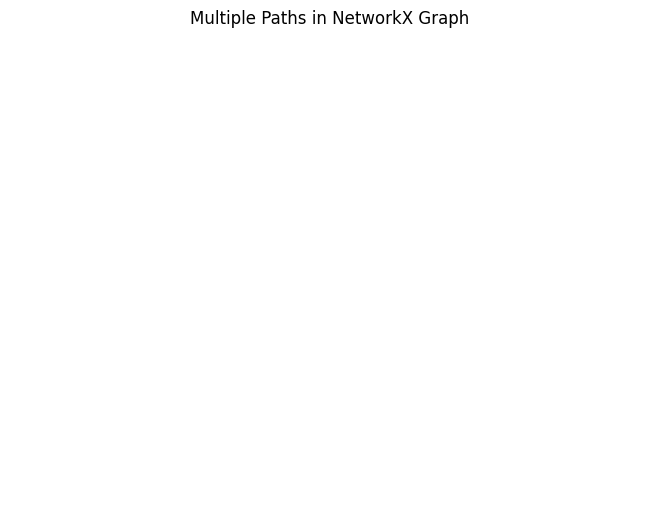

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


# Example: multiple paths as lists of nodes
#paths = df_min_weight_paths['path']
paths = df_shortest_paths_with_weight['path']
# Create an empty graph
G = nx.DiGraph()

# Add edges from all paths
for path in paths:
# Add edges for consecutive pairs of nodes in the path
    edges_G = list(zip(path[:-1], path[1:]))
    G.add_edges_from(edges_G)

# Draw the graph
pos = nx.spring_layout(G, scale=2,k=0.85, iterations=50) # Layout algorithm for positions
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)

# Optionally highlight each path in a different colour
colors = ['red', 'green', 'blue', 'purple']
for path, color in zip(paths, colors):
    edges_zip = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=edges_zip, edge_color=color, width=2)
#plt.figure(figsize=(12, 8))
plt.title("Multiple Paths in NetworkX Graph")
plt.show()

In [ ]:
len(tier0_node_ids)

265

In [ ]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight
# df_max1 = []

# df_max1 = df[(df['source'].isin(tier2_node_ids))]# & (df['target'].isin(tier0_node_ids))]

df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]
#d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]

#df.columns = ["source", "target", "path", "weight"]
#sample = df.sample(500, random_state = 1)
#sample.head(10)

G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if int(node) in tier0_node_ids:
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        height=6
    elif int(node) in tier1_node_ids:
        colors.append('orange')
        height=4
    elif int(node) in tier2_node_ids:
        colors.append('green')
        height=2
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
# G.graph['ranksep'] = '1.0' # Increase separation between ranks
# G.graph['nodesep'] = '4.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
pos = pydot_layout(G, prog="twopi")#, root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=750, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name_max = suf + '_max_twopi_graph.pdf'
plt.savefig(graph_name_max, format="pdf")
plt.show()

In [ ]:
print(nodes[nodes['id'] == 3167])
print(nodes[nodes['id'] == 3366])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


In [ ]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight

df_min_weight =2
#df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['target'].isin(tier0_node_ids))]



G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if int(node) in tier0_node_ids:
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        height=6
    elif int(node) in tier1_node_ids:
        colors.append('orange')
        height=4
    elif int(node) in tier2_node_ids:
        colors.append('green')
        height=2
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
G.graph['ranksep'] = '2.0' # Increase separation between ranks
G.graph['nodesep'] = '3.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
pos = pydot_layout(G, prog="twopi", root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name = suf + '_min_twopi_graph.pdf'
plt.savefig(graph_name, format="pdf")
plt.show()


In [ ]:
print(nodes[nodes['id'] == 3167])
print(nodes[nodes['id'] == 3366])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


In [ ]:
# admin_nodes = nodes[
#     nodes['properties'].apply(
#         lambda x: isinstance(x, dict) and 'name' in x and 'administrator' in x['name'].lower()
#     )
# ]
# display(admin_nodes)

In [ ]:

edges.head()

,id,source,source_node,target,target_node,type,label,weight
0,0,4248,Domain,4249,OU,relationship,Contains,2
1,1,4248,Domain,4250,OU,relationship,Contains,2
2,2,4248,Domain,4251,OU,relationship,Contains,2
3,3,4249,OU,4252,OU,relationship,Contains,2
4,4,4249,OU,4253,OU,relationship,Contains,2


In [ ]:
df_shortest_paths_with_weight.info()


tier2_node_ids = [int(node_id) for node_id in tier2_node_ids]
print(f"Type of elements in tier2_node_ids after conversion: {type(tier2_node_ids[0]) if tier2_node_ids else 'List is empty'}")

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   source        0 non-null      int64 
 1   target        0 non-null      int64 
 2   path          0 non-null      object
 3   total_weight  0 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 0.0+ bytes
Type of elements in tier2_node_ids after conversion: <class 'int'>


In [ ]:
import pandas as pd
from pyvis.network import Network
#pyvis.__version__

#Loading the data
#data = pd.read_csv("facebook_combined.txt", sep=" ", header=None)
df=df_shortest_paths_with_weight


df_min_weight =2
#df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['target'].isin(tier0_node_ids))]

net = Network(notebook = True, cdn_resources = "in_line",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True
)
net.repulsion()
for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids:
        net.add_node(str(node), label=str(node), color='red') # Added label for better visualization
      else:
        net.add_node(str(node), label=str(node), color='green')

    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight}") # Added weight and title to edge
#suf="vul1k"
graph_name = suf + '_min_graph.html'
net.show(graph_name)

5k_min_graph.html


In [ ]:


df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]







#df.columns = ["source", "target", "path", "weight"]
#sample = df.sample(500, random_state = 1)
#sample.head(10)

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True
)
net.repulsion()

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids:
        net.add_node(str(node), label=str(node), color='red') # Added label for better visualization
      elif node in tier1_node_ids:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids:
        net.add_node(str(node), label=str(node), color='green')
      else:
        net.add_node(str(node), label=str(node), color='yellow')

    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight}") # Added weight and title to edge
graph_name = suf + '_max_graph.html'
net.show(graph_name)

5k_max_graph.html


In [ ]:
for index, row in df_max.iterrows():
    path = row['path']
    print(f"Path: {path}")
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            # Get the properties and check for 'name' and Tier information
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = node_info.iloc[0]['Tier0'] == 1
            is_tier1 = node_info.iloc[0]['Tier1'] == 1
            is_tier2 = node_info.iloc[0]['Tier2'] == 1
            print(f"  Node ID: {node_id}, Name: {node_name}, Tier0: {is_tier0}, Tier1: {is_tier1}, Tier2: {is_tier2}")
        else:
            print(f"  Node ID: {node_id} not found in nodes DataFrame.")
    print("-" * 20)

In [ ]:
filtered_shortest_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == 1]
display(filtered_shortest_paths)

,source,target,path,total_weight


In [ ]:
# Create a list to store the data for the table
table_data = []

# Iterate through the paths in df_max
for index, row in df_max.iterrows():
    path = row['path']
    # path_str = " -> ".join(map(str, path)) # Convert the path list to a string

    # Iterate through the nodes in the current path
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = 1 if node_info.iloc[0]['Tier0'] == 1 else 0
            is_tier1 = 1 if node_info.iloc[0]['Tier1'] == 1 else 0
            is_tier2 = 1 if node_info.iloc[0]['Tier2'] == 1 else 0

            # Append the data as a dictionary to the list
            table_data.append({
                'Node Id': node_id, # Changed 'path' to 'Node Id' and stored node_id
                'Name': node_name,
                'Tier 0': is_tier0,
                'Tier 1': is_tier1,
                'Tier 2': is_tier2
            })

# Create a pandas DataFrame from the list of dictionaries
df_path_info = pd.DataFrame(table_data)

# Display the DataFrame
display(df_path_info)

""


In [ ]:
latex_table = df_path_info.to_latex(index=False)

file_name = suf + "_max_paths_table.tex"

with open(file_name, 'w') as f:
    f.write(latex_table)

print(f"Table exported to {file_name}")

Table exported to 5k_max_paths_table.tex


/content/adsync directory created.
